In [36]:
import warnings
warnings.filterwarnings('ignore')

# Using Transformerss

Transformer models are usually very large. With millions to tens of billions of parameters, training and deploying these models is a complicated undertaking. Furthermore, with new models being released on a near-daily basis and each having its own implementation, trying them all out is no easy task.


The 🤗 Transformers library was created to solve this problem. Its goal is to provide a single API through which any Transformer model can be loaded, trained, and saved. The library’s main features are:


* Ease of use: Downloading, loading, and using a state-of-the-art NLP model for inference can be done in just two lines of code.


* Flexibility: At their core, all models are simple PyTorch nn.Module or TensorFlow tf.keras.Model classes and can be handled like any other models in their respective machine learning (ML) frameworks.


* Simplicity: Hardly any abstractions are made across the library. The “All in one file” is a core concept: a model’s forward pass is entirely defined in a single file, so that the code itself is understandable and hackable.


This last feature makes 🤗 Transformers quite different from other ML libraries. The models are not built on modules that are shared across files; instead, each model has its own layers. In addition to making the models more approachable and understandable, this allows you to easily experiment on one model without affecting others

## Behind the pipeline

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier([
    "I m enjoying hugging face so far",
    "I hate bottom up apporach"
])

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'POSITIVE', 'score': 0.9998729228973389},
 {'label': 'NEGATIVE', 'score': 0.991349458694458}]

### Preprocessing with a tokenizer


Like other neural networks, Transformer models can’t process raw text directly, so the first step of our pipeline is to convert the text inputs into numbers that the model can make sense of. To do this we use a tokenizer, which will be responsible for:

* Splitting the input into words, subwords, or symbols (like punctuation) that are called tokens
* Mapping each token to an integer
* Adding additional inputs that may be useful to the model


All this preprocessing needs to be done in exactly the same way as when the model was pretrained, so we first need to download that information from the Model Hub. To do this, we use the AutoTokenizer class and its from_pretrained() method. Using the checkpoint name of our model, it will automatically fetch the data associated with the model’s tokenizer and cache it (so it’s only downloaded the first time we run the code below).


Since the default checkpoint of the sentiment-analysis pipeline is distilbert-base-uncased-finetuned-sst-2-english, we are running the following code.

In [ ]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

Once we have the tokenizer, we can directly pass our sentences to it and we’ll get back a dictionary that’s ready to feed to our model! The only thing left to do is to convert the list of input IDs to tensors.


We can use 🤗 Transformers without having to worry about which ML framework is used as a backend; it might be PyTorch or TensorFlow, or Flax for some models. However, Transformer models only accept tensors as input. If this is your first time hearing about tensors, you can think of them as NumPy arrays instead. A NumPy array can be a scalar (0D), a vector (1D), a matrix (2D), or have more dimensions. It’s effectively a tensor; other ML frameworks’ tensors behave similarly, and are usually as simple to instantiate as NumPy arrays.


To specify the type of tensors we want to get back (PyTorch, TensorFlow, or plain NumPy), we use the return_tensors argument:

In [ ]:
raw_inputs = [
    "I m enjoying hugging face so far, I m loving it!",
    "I hate bottom up apporach"
]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, 
                   return_tensors="pt")

for key, val in inputs.items():
    print(key, ":", val, end="\n\n\n")

input_ids : tensor([[  101,  1045,  1049,  9107, 17662,  2227,  2061,  2521,  1010,  1045,
          1049,  8295,  2009,   999,   102],
        [  101,  1045,  5223,  3953,  2039, 10439,  6525,  2818,   102,     0,
             0,     0,     0,     0,     0]])


attention_mask : tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]])




The output itself is a dictionary containing two keys, input_ids and attention_mask. input_ids contains two rows of integers (one for each sentence) that are the unique identifiers of the tokens in each sentence. 

### Going through the model

We can download our pretrained model the same way we did with our tokenizer. 🤗 Transformers provides an AutoModel class which also has a from_pretrained() method:

In [ ]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)

Some weights of the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english were not used when initializing DistilBertModel: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0): TransformerBlock(
        (attention): MultiHeadSelfAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(i

In this code snippet, we have downloaded the same checkpoint we used in our pipeline before (it should actually have been cached already) and instantiated a model with it.

This architecture contains only the base Transformer module: given some inputs, it outputs what we’ll call hidden states, also known as features. For each model input, we’ll retrieve a high-dimensional vector representing the **contextual understanding of that input by the Transformer model.**


While these hidden states can be useful on their own, they’re usually inputs to another part of the model, known as the head. In notebook 1, the different tasks could have been performed with the same architecture, but each of these tasks will have a different head associated with it.

### A high-dimensional vector?


The vector output by the Transformer module is usually large. It generally has three dimensions:

* Batch size: The number of sequences processed at a time (2 in our example).
* Sequence length: The length of the numerical representation of the sequence (16 in our example).
* Hidden size: The vector dimension of each model input.


It is said to be “high dimensional” because of the last value. The hidden size can be very large (768 is common for smaller models, and in larger models this can reach 3072 or more).

In [ ]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

torch.Size([2, 15, 768])


Note that the outputs of 🤗 Transformers models behave like namedtuples or dictionaries. You can access the elements by attributes (like we did) or by key (outputs["last_hidden_state"]), or even by index if you know exactly where the thing you are looking for is (outputs[0]).

### Model heads: Making sense out of numbers

The model heads take the high-dimensional vector of hidden states as input and project them onto a different dimension. They are usually composed of one or a few linear layers.
The output of the Transformer model is sent directly to the model head to be processed.


the model is represented by its embeddings layer and the subsequent layers. The embeddings layer converts each input ID in the tokenized input into a vector that represents the associated token. The subsequent layers manipulate those vectors using the attention mechanism to produce the final representation of the sentences.


There are many different architectures available in 🤗 Transformers, with each one designed around tackling a specific task. Here is a non-exhaustive list:

* Model (retrieve the hidden states)
* ForCausalLM
* ForMaskedLM
* ForMultipleChoice
* ForQuestionAnswering
* ForSequenceClassification
* ForTokenClassification
* and others 🤗


For our example, we will need a model with a sequence classification head (to be able to classify the sentences as positive or negative). So, we won’t actually use the AutoModel class, but AutoModelForSequenceClassification:

In [ ]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)

Now if we look at the shape of our inputs, the dimensionality will be much lower: the model head takes as input the high-dimensional vectors we saw before, and outputs vectors containing two values (one per label):

In [ ]:
print(outputs.logits.shape)

torch.Size([2, 2])


Since we have just two sentences and two labels, the result we get from our model is of shape 2 x 2.

### Postprocessing the output

The values we get as output from our model don’t necessarily make sense by themselves. Let’s take a look:

In [ ]:
print(outputs.logits)

tensor([[-4.3218,  4.7108],
        [ 2.5695, -2.1720]], grad_fn=<AddmmBackward0>)


Our model predicted [-1.5607, 1.6123] for the first sentence and [ 4.1692, -3.3464] for the second one. Those are not probabilities but logits, the raw, unnormalized scores outputted by the last layer of the model. To be converted to probabilities, they need to go through a SoftMax layer (all 🤗 Transformers models output the logits, as the loss function for training will generally fuse the last activation function, such as SoftMax, with the actual loss function, such as cross entropy):

In [ ]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions.float())

tensor([[1.1944e-04, 9.9988e-01],
        [9.9135e-01, 8.6505e-03]], grad_fn=<SoftmaxBackward0>)


Now we can see that the model predicted **[0.00019, 0.9998]** for the first sentence and **[0.9135, 0.00865]** for the second one. These are recognizable probability scores.


To get the labels corresponding to each position, we can inspect the id2label attribute of the model config (more on this in the next section):

In [ ]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

Now we can conclude that the model predicted the following:

First sentence: NEGATIVE: 0.00019, POSITIVE: 0.9998
Second sentence: NEGATIVE: 0.9135, POSITIVE: 0.00865


We have successfully reproduced the three steps of the pipeline: preprocessing with tokenizers, passing the inputs through the model, and postprocessing!.

## Models


The AutoModel class and all of its relatives are actually simple wrappers over the wide variety of models available in the library. It’s a clever wrapper as it can automatically guess the appropriate model architecture for your checkpoint, and then instantiates a model with this architecture.


However, if you know the type of model you want to use, you can use the class that defines its architecture directly. Let’s take a look at how this works with a BERT model.

### Creating a transformer

The first thing we’ll need to do to initialize a BERT model is load a configuration object:

In [ ]:
from transformers import BertConfig, BertModel

config = BertConfig()
model = BertModel(config)

The configuration contains many attributes that are used to build the model:

In [ ]:
print(config)

BertConfig {
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.21.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



### Different loading methods


Creating a model from the default configuration initializes it with random values.


The model can be used in this state, but it will output gibberish; it needs to be trained first. We could train the model from scratch on the task at hand, but as you saw in Chapter 1, this would require a long time and a lot of data, and it would have a non-negligible environmental impact. To avoid unnecessary and duplicated effort, it’s imperative to be able to share and reuse models that have already been trained.


Loading a Transformer model that is already trained is simple — we can do this using the from_pretrained() method:

In [ ]:
model = BertModel.from_pretrained("bert-base-cased")

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


We could replace BertModel with the equivalent AutoModel class. We’ll do this from now on as this produces checkpoint-agnostic code; if your code works for one checkpoint, it should work seamlessly with another. This applies even if the architecture is different, as long as the checkpoint was trained for a similar task (for example, a sentiment analysis task).


In the code sample above we didn’t use BertConfig, and instead loaded a pretrained model via the bert-base-cased identifier. This is a model checkpoint that was trained by the authors of BERT themselves; 


This model is now initialized with all the weights of the checkpoint. It can be used directly for inference on the tasks it was trained on, and it can also be fine-tuned on a new task. By training with pretrained weights rather than from scratch, we can quickly achieve good results.


The weights have been downloaded and cached (so future calls to the from_pretrained() method won’t re-download them) in the cache folder, which defaults to ~/.cache/huggingface/transformers. You can customize your cache folder by setting the HF_HOME environment variable.


The identifier used to load the model can be the identifier of any model on the Model Hub, as long as it is compatible with the BERT architecture.

### Saving methods

Saving a model is as easy as loading one — we use the save_pretrained() method, which is analogous to the from_pretrained() method:

In [ ]:
model.save_pretrained("sav_models/bert")

In [ ]:
ls sav_models/bert

config.json  pytorch_model.bin


In the config.json file, there are attributes necessary to build the model architecture. This file also contains some metadata, such as where the checkpoint originated and what 🤗 Transformers version you were using when you last saved the checkpoint.


The pytorch_model.bin file is known as the state dictionary; it contains all your model’s weights. The two files go hand in hand; the configuration is necessary to know model’s architecture, while the model weights are the model’s parameters.


### Using a Transformer model for inference

Transformer models can only process numbers — numbers that the tokenizer generates. But before we discuss tokenizers, let’s explore what inputs the model accepts.


Tokenizers can take care of casting the inputs to the appropriate framework’s tensors, we’ll take a quick look at what must be done before sending the inputs to the model.

In [ ]:
# let's say we have a couple of sequences:

sequences = ["Hello!", "Cool.", "Nice!"]

The tokenizer converts these to vocabulary indices which are typically called input IDs. Each sequence is now a list of numbers! The resulting output is:

In [ ]:
encoded_sequences = [
    [101, 7592, 999, 102],
    [101, 4658, 1012, 102],
    [101, 3835, 999, 102],
]

This is a list of encoded sequences: a list of lists. Tensors only accept rectangular shapes (think matrices). This “array” is already of rectangular shape, so converting it to a tensor is easy:

In [ ]:
import torch

model_inputs = torch.tensor(encoded_sequences)
model_inputs

tensor([[ 101, 7592,  999,  102],
        [ 101, 4658, 1012,  102],
        [ 101, 3835,  999,  102]])

### Using the tensors as inputs to the model


Making use of the tensors with the model is extremely simple — we just call the model with the inputs:

In [ ]:
output = model(model_inputs)
print(output.last_hidden_state.shape)

torch.Size([3, 4, 768])


While the model accepts a lot of different arguments, only the input IDs are necessary.

## Tokenizers

Tokenizers are one of the core components of the NLP pipeline. They serve one purpose: to translate text into data that can be processed by the model. Models can only process numbers, so tokenizers need to convert our text inputs to numerical data.

In NLP tasks, the data that is generally processed is raw text. Here’s an example of such text:
``nine tailed beast is on another level``


However, models can only process numbers, so we need to find a way to convert the raw text to numbers. That’s what the tokenizers do, and there are a lot of ways to go about this. The goal is to find the most meaningful representation — that is, the one that makes the most sense to the model — and, if possible, the smallest representation.


### Word-based tokenizer

The first type of tokenizer that comes to mind is word-based. It’s generally very easy to set up and use with only a few rules, and it often yields decent results. For example, the goal is to split the raw text into words and find a numerical representation for each of them.


There are different ways to split the text. For example, we could could use whitespace to tokenize the text into words by applying Python’s split() function:

In [ ]:
tokenized_text = "Sample text for tokenization techs".split()
tokenized_text

['Sample', 'text', 'for', 'tokenization', 'techs']

There are also variations of word tokenizers that have extra rules for punctuation. With this kind of tokenizer, we can end up with some pretty large “vocabularies,” where a vocabulary is defined by the total number of independent tokens that we have in our corpus.


Each word gets assigned an ID, starting from 0 and going up to the size of the vocabulary. The model uses these IDs to identify each word.


If we want to completely cover a language with a word-based tokenizer, we’ll need to have an identifier for each word in the language, which will generate a huge amount of tokens. For example, there are over 500,000 words in the English language, so to build a map from each word to an input ID we’d need to keep track of that many IDs. Furthermore, words like “dog” are represented differently from words like “dogs”, and the model will initially have no way of knowing that “dog” and “dogs” are similar: it will identify the two words as unrelated. The same applies to other similar words, like “run” and “running”, which the model will not see as being similar initially.


Finally, we need a custom token to represent words that are not in our vocabulary. This is known as the “unknown” token, often represented as ”[UNK]” or ””. It’s generally a bad sign if you see that the tokenizer is producing a lot of these tokens, as it wasn’t able to retrieve a sensible representation of a word and you’re losing information along the way. The goal when crafting the vocabulary is to do it in such a way that the tokenizer tokenizes as few words as possible into the unknown token.


One way to reduce the amount of unknown tokens is to go one level deeper, using a character-based tokenizer.


### Character-based


Character-based tokenizers split the text into characters, rather than words. This has two primary benefits:

The vocabulary is much smaller.
There are much fewer out-of-vocabulary (unknown) tokens, since every word can be built from characters.
But here too some questions arise concerning spaces and punctuation:

In [ ]:
text = "Sample text for tokenization techs"
character_tokenized = [i for i in list(text) if i != ' ']
print(character_tokenized)

['S', 'a', 'm', 'p', 'l', 'e', 't', 'e', 'x', 't', 'f', 'o', 'r', 't', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', 't', 'e', 'c', 'h', 's']


This approach isn’t perfect either. Since the representation is now based on characters rather than words, one could argue that, intuitively, it’s less meaningful: each character doesn’t mean a lot on its own, whereas that is the case with words. However, this again differs according to the language; in Chinese, for example, each character carries more information than a character in a Latin language.


Another thing to consider is that we’ll end up with a very large amount of tokens to be processed by our model: whereas a word would only be a single token with a word-based tokenizer, it can easily turn 
into 10 or more tokens when converted into characters.


To get the best of both worlds, we can use a third technique that combines the two approaches: subword tokenization.



### Subword tokenization


Subword tokenization algorithms rely on the principle that frequently used words should not be split into smaller subwords, but rare words should be decomposed into meaningful subwords.


For instance, “annoyingly” might be considered a rare word and could be decomposed into “annoying” and “ly”. These are both likely to appear more frequently as standalone subwords, while at the same time the meaning of “annoyingly” is kept by the composite meaning of “annoying” and “ly”.


Here is an example showing how a subword tokenization algorithm would tokenize the sequence “Let’s do tokenization!“:

``Let's</w>  |  do</w>  |  token  | ization</w>  | !</w>``


These subwords end up providing a lot of semantic meaning: for instance, in the example above “tokenization” was split into “token” and “ization”, two tokens that have a semantic meaning while being space-efficient (only two tokens are needed to represent a long word). This allows us to have relatively good coverage with small vocabularies, and close to no unknown tokens.


This approach is especially useful in agglutinative languages such as Turkish, where you can form (almost) arbitrarily long complex words by stringing together subwords.


**And more!**

Unsurprisingly, there are many more techniques out there. To name a few:


* Byte-level BPE, as used in GPT-2
* WordPiece, as used in BERT
* SentencePiece or Unigram, as used in several multilingual models


### Loading and saving

Loading and saving tokenizers is as simple as it is with models. Actually, it’s based on the same two methods: from_pretrained() and save_pretrained(). These methods will load or save the algorithm used by the tokenizer (a bit like the architecture of the model) as well as its vocabulary (a bit like the weights of the model).


Loading the BERT tokenizer trained with the same checkpoint as BERT is done the same way as loading the model, except we use the BertTokenizer class:

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

Similar to AutoModel, the AutoTokenizer class will grab the proper tokenizer class in the library based on the checkpoint name, and can be used directly with any checkpoint:

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [ ]:
# using tokenizer now as we did in the previous notebook
tokenizer(text)

{'input_ids': [101, 2687, 7136, 3087, 1111, 22559, 2734, 13395, 1116, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
# saving a tokenizer is identical to saving a model:
tokenizer.save_pretrained("sav_tokenizer/bert_tokenizer")

('sav_tokenizer/bert_tokenizer/tokenizer_config.json',
 'sav_tokenizer/bert_tokenizer/special_tokens_map.json',
 'sav_tokenizer/bert_tokenizer/vocab.txt',
 'sav_tokenizer/bert_tokenizer/added_tokens.json',
 'sav_tokenizer/bert_tokenizer/tokenizer.json')

let’s see how the input_ids are generated. To do this, we’ll need to look at the intermediate methods of the tokenizer.

### Enocoding

Translating text to numbers is known as encoding. Encoding is done in a two-step process: the tokenization, followed by the conversion to input IDs.


As we’ve seen, the first step is to split the text into words (or parts of words, punctuation symbols, etc.), usually called tokens. There are multiple rules that can govern that process, which is why we need to instantiate the tokenizer using the name of the model, to make sure we use the same rules that were used when the model was pretrained.


### Tokenization

The tokenization process is done by the tokenize() method of the tokenizer:

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
sequence = text

tokens = tokenizer.tokenize(sequence)
print(tokens)

['Sam', '##ple', 'text', 'for', 'token', '##ization', 'tech', '##s']


This tokenizer is a subword tokenizer: it splits the words until it obtains tokens that can be represented by its vocabulary. That’s the case here with transformer, which is split into two tokens: Sam ##ple.

### From tokens to input IDs

The conversion to input IDs is handled by the convert_tokens_to_ids() tokenizer method:

In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids)

[2687, 7136, 3087, 1111, 22559, 2734, 13395, 1116]


These outputs, once converted to the appropriate framework tensor, can then be used as inputs to a model.

### Decoding

Decoding is going the other way around: from vocabulary indices, we want to get a string. This can be done with the decode() method as follows:

In [ ]:
tokenizer.decode(ids)

'Sample text for tokenization techs'

The decode method not only converts the indices back to tokens, but also groups together the tokens that were part of the same words to produce a readable sentence. This behavior will be extremely useful when we use models that predict new text (either text generated from a prompt, or for sequence-to-sequence problems like translation or summarization).

## Handling multiple sequences

### Models expect a batch of inputs

Let’s convert a list of numbers to a tensor and send it to the model:

In [14]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [15]:
checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0): TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
       

In [16]:
sequence = "Let's just study and make some good projects!"
tokens = tokenizer.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)
input_ids = torch.tensor(ids)

In [17]:
model(input_ids)

IndexError: ignored

The problem is that we sent a single sequence to the model, whereas 🤗 Transformers models expect multiple sentences by default. Here we tried to do everything the tokenizer did behind the scenes when we applied it to a sequence,

In [18]:
tokenized_inputs = tokenizer(sequence, return_tensors="pt")
print(tokenized_inputs["input_ids"])

tensor([[ 101, 2292, 1005, 1055, 2074, 2817, 1998, 2191, 2070, 2204, 3934,  999,
          102]])


it added a dimension before it

In [19]:
input_ids = torch.tensor([ids])
print(input_ids)

tensor([[2292, 1005, 1055, 2074, 2817, 1998, 2191, 2070, 2204, 3934,  999]])


In [20]:
yh = model(input_ids)
print(yh.logits)

tensor([[-3.0242,  3.1971]], grad_fn=<AddmmBackward0>)


In [21]:
print(model.config.id2label)

{0: 'NEGATIVE', 1: 'POSITIVE'}


In [22]:
from torch.nn.functional import softmax

print(softmax(yh.logits))

tensor([[0.0020, 0.9980]], grad_fn=<SoftmaxBackward0>)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  This is separate from the ipykernel package so we can avoid doing imports until


Nevative Prob: 0.0020
Positive Prob: 0.9980

seq: "Let's just study and make some good projects!"


Batching is the act of sending multiple sentences through the model, all at once. If you only have one sentence, you can just build a batch with a single sequence:

In [23]:
batched_ids = [ids, ids]

This is a batch of two identical sequences!


Batching allows the model to work when you feed it multiple sentences. Using multiple sequences is just as simple as building a batch with a single sequence. There’s a second issue, though. When you’re trying to batch together two (or more) sentences, they might be of different lengths. If you’ve ever worked with tensors before, you know that they need to be of rectangular shape, so you won’t be able to convert the list of input IDs into a tensor directly. To work around this problem, we usually pad the inputs.

### Padding the inputs

The following list of lists cannot be converted to a tensor:

In [24]:
batched_ids = [
    [200, 200, 200],
    [200, 200]
]

In order to work around this, we’ll use padding to make our tensors have a rectangular shape. Padding makes sure all our sentences have the same length by adding a special word called the padding token to the sentences with fewer values. For example, if you have 10 sentences with 10 words and 1 sentence with 20 words, padding will ensure all the sentences have 20 words. In our example, the resulting tensor looks like this:

In [25]:
padding_id = 100

batched_ids = [
    [200, 200, 200],
    [200, 200, padding_id],
]

The padding token ID can be found in tokenizer.pad_token_id. Let’s use it and send our two sentences through the model individually and batched together:

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

seq1_ids = [200, 200, 200]
seq2_ids = [200, 200]

batch_ids = [seq1_ids, seq2_ids + [tokenizer.pad_token_id]]

In [37]:
yh = model(torch.tensor([seq1_ids])).logits
print(yh)

print("\n\n", softmax(yh))

tensor([[ 1.5694, -1.3895]], grad_fn=<AddmmBackward0>)


 tensor([[0.9507, 0.0493]], grad_fn=<SoftmaxBackward0>)


In [38]:
yh = model(torch.tensor([seq2_ids])).logits
print(yh)

print("\n\n", softmax(yh))

tensor([[ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>)


 tensor([[0.7297, 0.2703]], grad_fn=<SoftmaxBackward0>)


In [39]:
yh = model(torch.tensor(batched_ids)).logits
print(yh)

print("\n\n", softmax(yh))

tensor([[ 1.5694, -1.3895],
        [ 0.9907, -0.9139]], grad_fn=<AddmmBackward0>)


 tensor([[0.9507, 0.0493],
        [0.8704, 0.1296]], grad_fn=<SoftmaxBackward0>)


There’s something wrong with the logits in our batched predictions: the second row should be the same as the logits for the second sentence, but we’ve got completely different values!

This is because the key feature of Transformer models is attention layers that contextualize each token. These will take into account the padding tokens since they attend to all of the tokens of a sequence. To get the same result when passing individual sentences of different lengths through the model or when passing a batch with the same sentences and padding applied, we need to tell those attention layers to ignore the padding tokens. This is done by using an **attention mask**.


### Attention masks


Attention masks are tensors with the exact same shape as the input IDs tensor, filled with 0s and 1s: 1s indicate the corresponding tokens should be attended to, and 0s indicate the corresponding tokens should not be attended to (i.e., they should be ignored by the attention layers of the model).


Let’s complete the previous example with an attention mask:


In [49]:
batch_ids = [
    [200, 200, 200],
    [200, 200, tokenizer.pad_token_id]
]

attention_mask = [
    [1, 1, 1],
    [1, 1, 0]
]

In [50]:
yh = model(torch.tensor(batch_ids), attention_mask=torch.tensor(attention_mask))
print(yh)

SequenceClassifierOutput(loss=None, logits=tensor([[ 1.5694, -1.3895],
        [ 0.5803, -0.4125]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


Now we get the same logits for the second sentence in the batch.


Notice how the last value of the second sequence is a padding ID, which is a 0 value in the attention mask.

### Longer sequences


With Transformer models, there is a limit to the lengths of the sequences we can pass the models. Most models handle sequences of up to 512 or 1024 tokens, and will crash when asked to process longer sequences. There are two solutions to this problem:

* Use a model with a longer supported sequence length.
* Truncate your sequences.

Models have different supported sequence lengths, and some specialize in handling very long sequences. Longformer is one example, and another is LED.

example: sequence = sequence[:max_sequence_length]

## Putting it all together


hen you call your tokenizer directly on the sentence, you get back inputs that are ready to pass through your model:

In [54]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenzier = AutoTokenizer.from_pretrained(checkpoint)

sequence = """
With Transformer models, there is a limit to the lengths of the sequences
we can pass the models. Most models handle sequences of up to 512 or 1024 tokens,
and will crash when asked to process longer sequences.
There are two solutions to this problem
"""

model_inputs = tokenzier(sequence)
model_inputs

{'input_ids': [101, 2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Here, the model_inputs variable contains everything that’s necessary for a model to operate well. For DistilBERT, that includes the input IDs as well as the attention mask. Other models that accept additional inputs will also have those output by the tokenizer object.

It can pad according to several objectives:



In [56]:
# it will pad the sequence up to the maximum sequence length
model_inputs = tokenzier(sequence, padding="longest")
model_inputs

{'input_ids': [101, 2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [59]:
# it will pad the sequences up to the model max length
# 512 for bert or distilBert
model_inputs = tokenzier(sequence, padding="max_length")
model_inputs

{'input_ids': [101, 2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [67]:
# it will pad the sequence up to the specified max length
model_inputs = tokenzier(sequence, padding="max_length", max_length=8)
model_inputs

{'input_ids': [101, 2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

It can also truncate sequences:

In [64]:
# Will truncate the sequences that are longer than the model max length
# 512 for bert or DistilBert 
model_inputs = tokenizer(sequence, truncation=True)
model_inputs

{'input_ids': [101, 2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [65]:
# Will truncate the sequences that are longer than the specified max length
model_inputs = tokenizer(sequence, truncation=True, max_length=8)
model_inputs

{'input_ids': [101, 2007, 10938, 2121, 4275, 1010, 2045, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

The tokenizer object can handle the conversion to specific framework tensors, which can then be directly sent to the model. For example, in the following code sample we are prompting the tokenizer to return tensors from the different frameworks — "pt" returns PyTorch tensors, "tf" returns TensorFlow tensors, and "np" returns NumPy arrays:

In [71]:
# returns pytorch tensors
pt = tokenizer(sequence, padding=True, return_tensors="pt")
print(pt)

# returns tensorflow tensors
tf = tokenizer(sequence, padding=True, return_tensors="tf")
print(tf)

# returns numpy arrays
npy = tokenizer(sequence, padding=True, return_tensors="np")
print(npy)

{'input_ids': tensor([[  101,  2007, 10938,  2121,  4275,  1010,  2045,  2003,  1037,  5787,
          2000,  1996, 10742,  1997,  1996, 10071,  2057,  2064,  3413,  1996,
          4275,  1012,  2087,  4275,  5047, 10071,  1997,  2039,  2000, 24406,
          2030,  9402,  2549, 19204,  2015,  1010,  1998,  2097,  5823,  2043,
          2356,  2000,  2832,  2936, 10071,  1012,  2045,  2024,  2048,  7300,
          2000,  2023,  3291,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1]])}
{'input_ids': <tf.Tensor: shape=(1, 54), dtype=int32, numpy=
array([[  101,  2007, 10938,  2121,  4275,  1010,  2045,  2003,  1037,
         5787,  2000,  1996, 10742,  1997,  1996, 10071,  2057,  2064,
         3413,  1996,  4275,  1012,  2087,  4275,  5047, 10071,  1997,
         2039,  2000, 24406,  2030,  9402,  2549, 19204,  2015,  10

### Special tokens

If we take a look at the input IDs returned by the tokenizer, we will see they are a tiny bit different from what we had earlier:

In [72]:
model_inputs = tokenizer(sequence)
print(model_inputs["input_ids"])

[101, 2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291, 102]


In [74]:
tokens = tokenzier.tokenize(sequence)
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids)

[2007, 10938, 2121, 4275, 1010, 2045, 2003, 1037, 5787, 2000, 1996, 10742, 1997, 1996, 10071, 2057, 2064, 3413, 1996, 4275, 1012, 2087, 4275, 5047, 10071, 1997, 2039, 2000, 24406, 2030, 9402, 2549, 19204, 2015, 1010, 1998, 2097, 5823, 2043, 2356, 2000, 2832, 2936, 10071, 1012, 2045, 2024, 2048, 7300, 2000, 2023, 3291]


One token ID was added at the beginning, and one at the end. Let’s decode the two sequences of IDs above to see what this is about:

In [76]:
tokenizer.decode(model_inputs["input_ids"])

'[CLS] with transformer models, there is a limit to the lengths of the sequences we can pass the models. most models handle sequences of up to 512 or 1024 tokens, and will crash when asked to process longer sequences. there are two solutions to this problem [SEP]'

In [77]:
tokenizer.decode(ids)

'with transformer models, there is a limit to the lengths of the sequences we can pass the models. most models handle sequences of up to 512 or 1024 tokens, and will crash when asked to process longer sequences. there are two solutions to this problem'

The tokenizer added the special word [CLS] at the beginning and the special word [SEP] at the end. This is because the model was pretrained with those, so to get the same results for inference we need to add them as well. Note that some models don’t add special words, or add different ones; models may also add these special words only at the beginning, or only at the end. In any case, the tokenizer knows which ones are expected 

### Wrapping up: From tokenizer to model

Let’s see one final time how it can handle multiple sequences (padding!), very long sequences (truncation!), and multiple types of tensors with its main API:

In [80]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

inputs_x = tokenizer(sequence, padding=True, truncation=True,
                     return_tensors="pt")
yh = model(**inputs_x)

In [83]:
print(yh)
print(softmax(yh.logits))

SequenceClassifierOutput(loss=None, logits=tensor([[ 3.9508, -3.1872]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
tensor([[9.9921e-01, 7.9373e-04]], grad_fn=<SoftmaxBackward0>)


## Section Recap

* Learned the basic building blocks of a Transformer model.

* Learned what makes up a tokenization pipeline.
Saw how to use a Transformer model in practice.

* Learned how to leverage a tokenizer to convert text to tensors that are understandable by the model.
* Set up a tokenizer and a model together to get from text to predictions.

* Learned the limitations of input IDs, and learned about attention masks.

* Played around with versatile and configurable tokenizer methods.

## End-of-chapter quiz

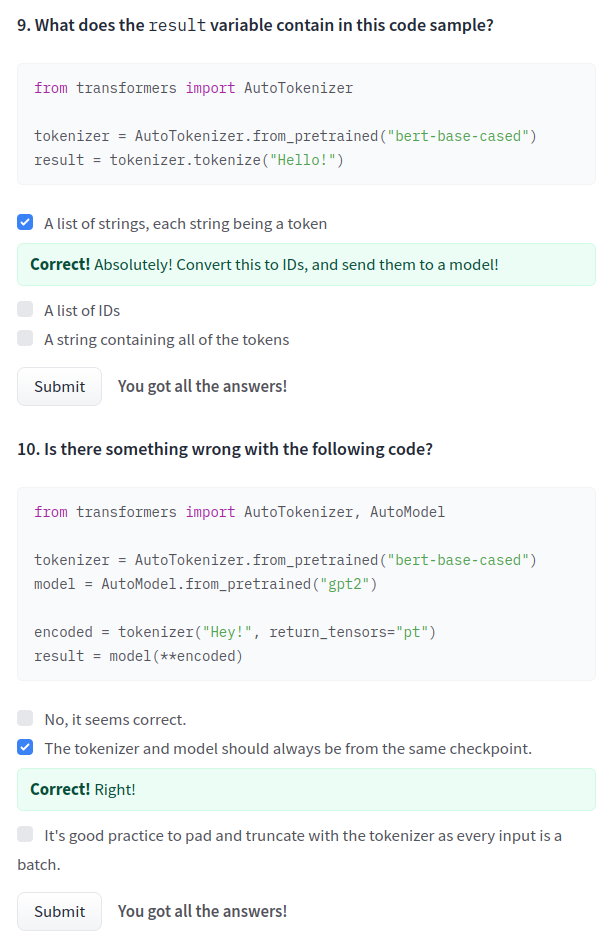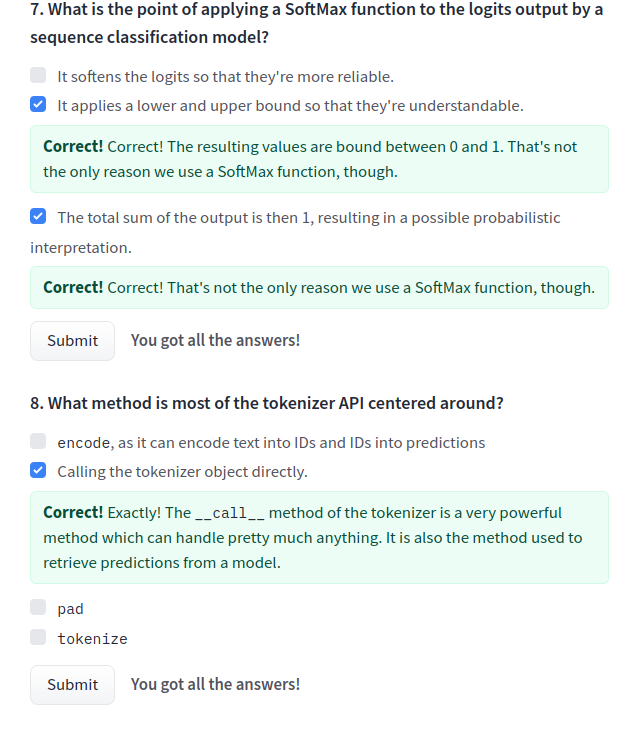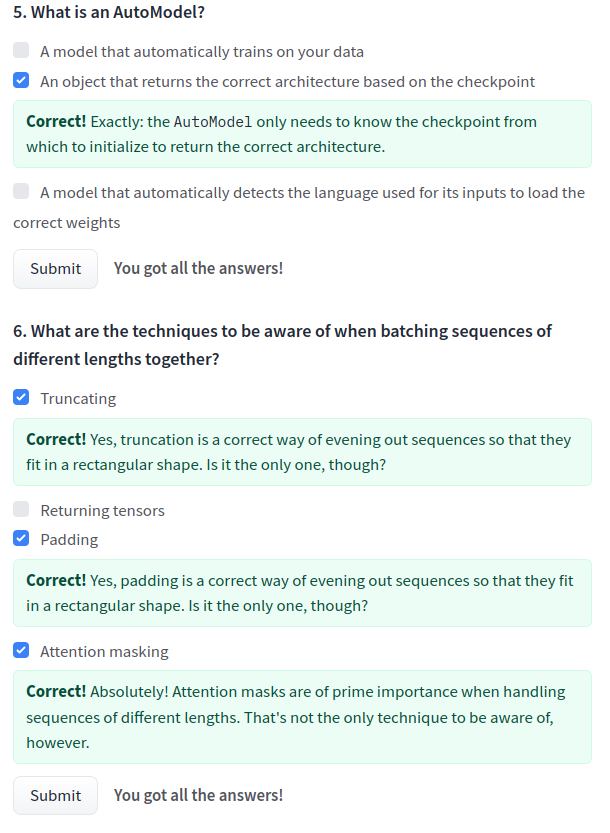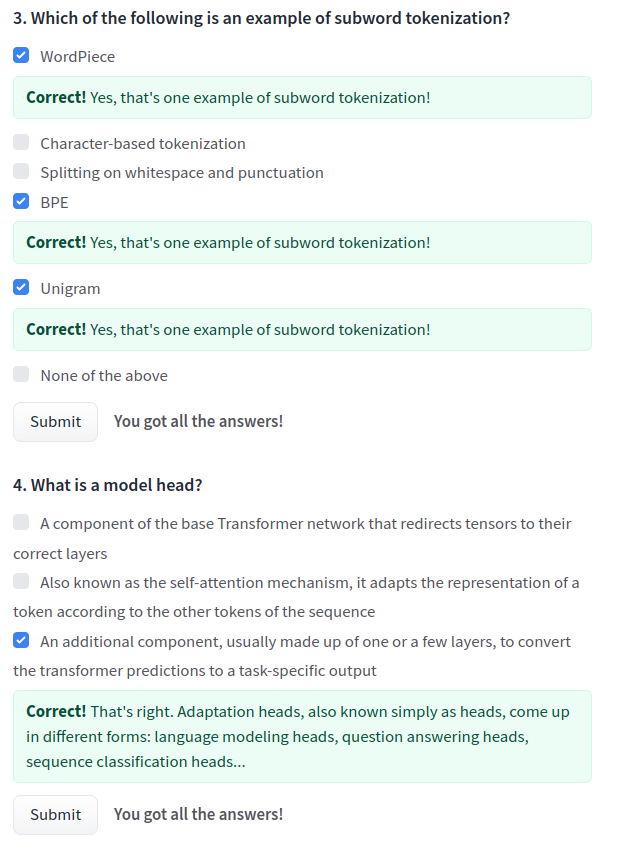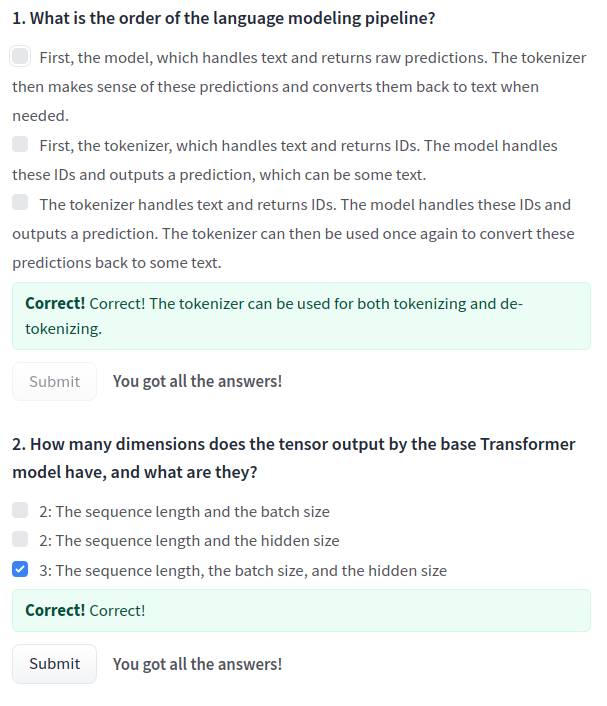

# Thank you for reading this.